# ITI5196 Assessment 2 Task1
#### Student Name: Eddy
#### Student ID: 33495068

Date: 13/11/2023

Version: 1.0

Environment: Python 3.10.11 and Jupyter notebook extension in VS code

Libraries used: please include the main libraries you used in your assignment here, e.g.,:
* pandas 
* re 
* numpy
* math
* mathplotlib.pyplot
* datetime
* collections
* difflib


<span style="color: red"> Note that this is a sample notebook only. You will need to fill in the proper markdown and code blocks. You might also want to make necessary changes to the structure to meet your own needs. It is important to make sure the logic of how you finish the assessment is clearly shown in this notebook! </span>

## Import libraries 

In [1]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import math
import re
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter
from difflib import SequenceMatcher

## Task 1. Auditing and cleansing the loaded data

Here, you should write your own code to audit data, identify data problems and to fix them. Also, record the found errors as required

<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

First to get the feel on how messy the data is, the data is loaded and visualized

In [2]:
dataset = pd.read_csv("dataset1_with_error.csv")
print(dataset.shape)
dataset.info()
dataset.head(10)

(55171, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55171 entries, 0 to 55170
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             55171 non-null  int64 
 1   Title          55171 non-null  object
 2   Location       55171 non-null  object
 3   Company        51322 non-null  object
 4   ContractType   33494 non-null  object
 5   ContractTime   47049 non-null  object
 6   Category       55171 non-null  object
 7   Salary         53586 non-null  object
 8   OpenDate       55171 non-null  object
 9   CloseDate      55171 non-null  object
 10  Source         55171 non-null  object
 11  NumberOfViews  52645 non-null  object
dtypes: int64(1), object(11)
memory usage: 5.1+ MB


,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,Source,NumberOfViews
0,12612628,Engineering Systems Analyst,Dorking,Gregory Martin International,NaN,permanent,Engineering Jobs,25000,20130708T120000,20130906T120000,cv-library.co.uk,19974
1,12612830,Stress Engineer Glasgow,Glasgow,Gregory Martin International,NaN,permanent,Engineering Jobs,30000,20120130T000000,20120330T000000,cv-library.co.uk,24034
2,12612844,Modelling and simulation analyst,Hampshire,Gregory Martin International,NaN,permanent,Engineering Jobs,30000,20121221T150000,20130120T150000,cv-library.co.uk,24024
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Surrey,Gregory Martin International,NaN,permanent,Engineering Jobs,27500,20131208T150000,20140206T150000,cv-library.co.uk,21999
4,12613647,"Pioneer, Miser Engineering Systems Analyst",Surrey,Gregory Martin International,NaN,permanent,Engineering Jobs,25000,20130302T120000,20130501T120000,cv-library.co.uk,19973
5,19047429,Trainee Mortgage Advisor East Midlands,East Midlands,Brite Recruitment,NaN,permanent,Accounting & Finance Jobs,21000,20130103T000000,20130403T000000,cv-library.co.uk,16776
6,20199757,"PROJECT ENGINEER, PHARMACEUTICAL",Witney,MatchBox Recruiting Ltd,NaN,permanent,Healthcare & Nursing Jobs,37500,20120412T150000,20120611T150000,cv-library.co.uk,30035
7,20797143,Chef de Partie Award Winning Restaurant Exce...,Derby,Chef Results,-,-,Hospitality & Catering Jobs,16000,20130328T120000,20130527T120000,caterer.com,12822
8,22579462,Quality Engineer,Gateshead,Asset Appointments,NaN,permanent,Engineering Jobs,22000,20131222T150000,20140220T150000,cv-library.co.uk,17613
9,22933091,Chef de Partie Award Winning Dining Live In ...,UK,Chef Results,-,-,Hospitality & Catering Jobs,18000,20131219T000000,20140102T000000,caterer.com,14433


Looking at the data it looks like the total rows should be 55171. While there are some columns that has 55171 data, other columns has missing values.

The column without missing values = Id, Title, Location, Category, OpenDate, CloseDate, Source

The column with missing values = Company, ContractType, ContractTime, Salary, NumberOfViews

# Id COLUMN

First investigating is there any duplicates or problems in the ID column

In [3]:
# Checking how many unique values are there in the ID column

print('Total unique values in ID column is: ', len(dataset.Id.unique()))

Total unique values in ID column is:  55171


The unique count result is 55171, it's the same number as the total rows. Therefore it can be surmised that there are exactly 55171 unique values. Same as the rows. Next to check if all the ID has 8 number or not.

In [4]:
#dataset[dataset.Salary.apply(lambda x: x == '20000000')]

In [5]:
#This code is to identify if there's any ID number that's not 8 digit. If there's any ID that's not 8 digit, it will print
#the code. The correct output is for no output

for x in dataset.Id.unique():
    if len(str(x)) == 8:
        continue
    else:
        print('This ID is not 8 digit')

The code didn't produce any output, so it can be infered that all Id are 8 digit and it satisfy the requirement of the schema. From the .info() done earlier it's also shown that the type of the data in Id column is integer so it match the schema.

Next column to be checked is the Source column

# Source

From the name alone, it's apparent what's the problem is. The column name is different from what the schema wanted. It should be SourceName so it should be changed.

In [6]:
#Code to change Source column name to SourceName

dataset = dataset.rename(columns={'Source': 'SourceName'})
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55171 entries, 0 to 55170
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             55171 non-null  int64 
 1   Title          55171 non-null  object
 2   Location       55171 non-null  object
 3   Company        51322 non-null  object
 4   ContractType   33494 non-null  object
 5   ContractTime   47049 non-null  object
 6   Category       55171 non-null  object
 7   Salary         53586 non-null  object
 8   OpenDate       55171 non-null  object
 9   CloseDate      55171 non-null  object
 10  SourceName     55171 non-null  object
 11  NumberOfViews  52645 non-null  object
dtypes: int64(1), object(11)
memory usage: 5.1+ MB


.info() is used again to see if the Source column name is changed or not. It can be seen that the name matched the schema now. Next to identify if there's any misspellings. The problem with website name is that there's a probability that even though the website doesn't exist anylonger it may exist sometime in the past so the wrangling on this part is focusing on searching for misspellings and such.

In [7]:
#Code to show all the website ordered by value counts function. Assume that the website without . is without .com etc
for x in dataset.SourceName.value_counts().index.to_list():
    if re.search('(\.)', x) == None:
        print(x)
    
    

Jobcentre Plus
MyUkJobs
GAAPweb
Brand Republic Jobs
eFinancialCareers
PR Week Jobs
Multilingualvacancies
Jobs Ac
Jobs24
ijobs
JobSearch
JustLondonJobs
Teaching jobs - TES Connect
TotallyExec


It's apparent that there's some name with mispellings in it because some of them didn't have .com/.co.uk/.net. To fix this, the correct name is googled then replaced with the correct one. 

TotallyExec
Teaching jobs - TES Connect
JustLondonJobs
JobSearch
ijobs
Jobs24
Jobs Ac
eFinancialCareers
Brand Republic Jobs
GAAPweb
MyUkJobs

In [8]:
#Code to replace the name with the correct one gotten from google
dataset.SourceName.replace({'TotallyExec': 'totallyexec.com', 'Teaching jobs - TES Connect': 'tes.com', 'JustLondonJobs': 'justlondonjobs.com',
                            'JobSearch': 'jobsearch.com', 'ijobs': 'ijobs.co.uk', 'Jobs24': 'jobs24.com', 'Jobs Ac': 'jobs.ac.uk',
                            'eFinancialCareers': 'efinancialcareers.co.uk', 'GAAPweb': 'gaapweb.com', 'MyUkJobs': 'myukjob.com',
                            'PR Week Jobs': 'prweekjobs.co.uk', 'Multilingualvacancies': '.multilingualvacancies.com'}, inplace=True)

For Brand Republic Jobs and Jobcentre Plus, the website is accompanying another website so it's left as it is. Next is Category column

# Category

First value_counts is used to see if there's any mispellings or not

In [9]:
#Value counts is used to see if there's any misspellings
for x, y in dataset.Category.value_counts().to_dict().items():
    print(x, '... count =', y)

IT Jobs ... count = 14341
Healthcare & Nursing Jobs ... count = 8808
Engineering Jobs ... count = 8209
Accounting & Finance Jobs ... count = 7136
Sales Jobs ... count = 5348
Hospitality & Catering Jobs ... count = 4789
Teaching Jobs ... count = 3778
PR, Advertising & Marketing Jobs ... count = 2752
Healthcare and Nursing Jobs ... count = 1
Sals Jobs ... count = 1
Teaching ... count = 1
Accounting AND Finance Jobs ... count = 1
Finance and Accounting ... count = 1
Engineerng Jobs ... count = 1
IT Jos ... count = 1
IT Josb ... count = 1
Engineering ... count = 1
Information Technology ... count = 1


From here we can see that there are a lots of data that only has one count and it's clearly a mispellings/case problem from the high count data. First we normalize the column to avoid case problems. Also and will be converted to & symbol

In [10]:
#Defining function to normalize the category by uppercasing the category and deleting spaces + trailing spaces

def normalizecategory(category):
    #function to skip null is not needed because we known there's no null in this column    
    # normalize to upper case letters        
    category = category.upper()
    # replace " AND " with " & "
    category = category.replace(" AND ", " & ")
    return category

#Applying the function
dataset['Category'] = dataset.Category.apply(lambda x: normalizecategory(x))

After the column is normalized, for loop with value counts is used again to see if there's still any mispellings

In [11]:
#Value counts is used to the result of the normalization and looking for other mistakes
for x, y in dataset.Category.value_counts().to_dict().items():
    print(x, '... count =', y)

IT JOBS ... count = 14341
HEALTHCARE & NURSING JOBS ... count = 8809
ENGINEERING JOBS ... count = 8209
ACCOUNTING & FINANCE JOBS ... count = 7137
SALES JOBS ... count = 5348
HOSPITALITY & CATERING JOBS ... count = 4789
TEACHING JOBS ... count = 3778
PR, ADVERTISING & MARKETING JOBS ... count = 2752
ENGINEERING ... count = 1
FINANCE & ACCOUNTING ... count = 1
IT JOSB ... count = 1
IT JOS ... count = 1
ENGINEERNG JOBS ... count = 1
TEACHING ... count = 1
SALS JOBS ... count = 1
INFORMATION TECHNOLOGY ... count = 1


Looks like there are some mispellings left. Replace function is used to correct the name according to the high count names.

In [12]:
#Code to correct the incorrect category names by replacing it with the correct names

dataset.Category.replace({'IT JOSB': 'IT JOBS', 'ENGINEERING': 'ENGINEERING JOBS', 'FINANCE & ACCOUNTING': 'ACCOUNTING & FINANCE JOBS',
                          'IT JOS': 'IT JOBS', 'ENGINEERNG JOBS': 'ENGINEERING JOBS', 'TEACHING': 'TEACHING JOBS',
                          'SALS JOBS': 'SALES JOBS', 'INFORMATION TECHNOLOGY': 'IT JOBS'}, inplace=True)

Next is ContractType

# ContractType

First value_counts is used to see if there's any mispellings or not

In [13]:
#Value counts is used to see if there's any misspellings

for x, y in dataset.ContractType.value_counts().to_dict().items():
    print(x, '... count =', y)

  ... count = 14903
full_time ... count = 12303
- ... count = 4720
part_time ... count = 1568


From the schema we can infer that there should be only 3 categories which is full_time, part_time, and non_specified so the wrong category should be corrected.



In [14]:
#Using .replace to replace the wrong category to change it as non_specified
dataset.ContractType.replace({' ': 'non_specified', '-': 'non_specified'}, inplace= True)

The remaining problems are missing data. To enter the missing values for categorical values, one way is to use mode() function to enter the missing values as the most common values from other column. The column that will be used to enter the missing values is by the category column.

In [15]:
#Function to use mode() to fill out Na in contract type grouping by category column
#f_ctype = lambda x:x.mode().iloc[0]
#dataset.ContractType = dataset.ContractType.fillna(dataset.groupby('Category').ContractType.transform(f_ctype))

next is ContractTime

# ContractTime

First value_counts is used to see if there's any mispellings or not

In [16]:
#Value counts is used to see if there's any misspellings

for x, y in dataset.ContractTime.value_counts().to_dict().items():
    print(x, '... count =', y)

permanent ... count = 33639
- ... count = 6249
contract ... count = 6089
  ... count = 1072


From the schema we can infer that there should be only 3 categories which is permanent, contract, and non-specified so the missing values and wrong category should be corrected.

In [17]:
#Using .replace to replace the wrong category and fillna to enter missing value as non_specified

dataset.ContractTime.replace({' ': 'non_specified', '-': 'non_specified'}, inplace= True)

The remaining problems are missing data. To enter the missing values for categorical values, one way is to use mode() function to enter the missing values as the most common values from other column. The column that will be used to enter the missing values is by the category column.

In [18]:
#Function to use mode() to fill out Na in contract time grouping by category column
#f_ctime = lambda x:x.mode().iloc[0]
#dataset.ContractTime = dataset.ContractTime.fillna(dataset.groupby('Category').ContractTime.transform(f_ctime))

Next is Location

# Location

First value_counts is used to see if there's any mispellings or not

In [19]:
#Value counts is used to see if there's any misspellings
for x, y in dataset.Location.value_counts().to_dict().items():
    print(x, '... count =', y)

UK ... count = 8398
London ... count = 7046
South East London ... count = 2962
The City ... count = 1184
Central London ... count = 889
Manchester ... count = 754
Leeds ... count = 733
Surrey ... count = 686
Birmingham ... count = 639
Reading ... count = 604
West Midlands ... count = 579
Bristol ... count = 471
Berkshire ... count = 441
East Sheen ... count = 437
Nottingham ... count = 409
Oxford ... count = 395
Hampshire ... count = 387
Sheffield ... count = 383
Milton Keynes ... count = 383
Kent ... count = 362
Cambridge ... count = 358
Newcastle Upon Tyne ... count = 346
Guildford ... count = 340
Leicester ... count = 311
Hertfordshire ... count = 301
Liverpool ... count = 286
Essex ... count = 282
Aberdeen ... count = 282
Oxfordshire ... count = 275
West Yorkshire ... count = 273
Cheshire ... count = 252
Basingstoke ... count = 237
North West London ... count = 237
Glasgow ... count = 229
West Sussex ... count = 229
Northampton ... count = 228
Slough ... count = 225
Buckinghamshire

By the values with only 1 count, looks like there are some mispellings and case problems. The column is corrected by normalizing the data by converting it to uppercase, deleting multiple spaces and trailing spaces.

In [20]:
#Defining function to normalize the location by uppercasing the location and deleting spaces + trailing spaces

def normalizelocation(location):
        #We know that location column doesn't have missing values do no need to deal with values
        # normalize to upper case letters
        location = location.upper()
        # replace multiple spaces with a single space, also trim spaces on both side
        return location
dataset['Location'] = dataset.Location.apply(lambda x: normalizelocation(x))

After normalizing the data, for loop with value counts is used to see if there are still problems with the data

In [21]:
#Value counts is used to see if there's any misspellings
for x, y in dataset.Location.value_counts().to_dict().items():
    print(x, '... count =', y)

UK ... count = 8398
LONDON ... count = 7048
SOUTH EAST LONDON ... count = 2962
THE CITY ... count = 1184
CENTRAL LONDON ... count = 889
MANCHESTER ... count = 754
LEEDS ... count = 733
SURREY ... count = 686
BIRMINGHAM ... count = 641
READING ... count = 604
WEST MIDLANDS ... count = 579
BRISTOL ... count = 472
BERKSHIRE ... count = 441
EAST SHEEN ... count = 437
NOTTINGHAM ... count = 409
OXFORD ... count = 395
HAMPSHIRE ... count = 389
SHEFFIELD ... count = 383
MILTON KEYNES ... count = 383
KENT ... count = 362
CAMBRIDGE ... count = 358
NEWCASTLE UPON TYNE ... count = 346
GUILDFORD ... count = 340
LEICESTER ... count = 311
HERTFORDSHIRE ... count = 301
LIVERPOOL ... count = 286
ABERDEEN ... count = 284
ESSEX ... count = 282
OXFORDSHIRE ... count = 275
WEST YORKSHIRE ... count = 273
CHESHIRE ... count = 252
NORTH WEST LONDON ... count = 237
BASINGSTOKE ... count = 237
WEST SUSSEX ... count = 229
GLASGOW ... count = 229
NORTHAMPTON ... count = 228
BUCKINGHAMSHIRE ... count = 225
SLOUGH

Seeing at the low value names, it's clear that they are mispellings from the high count name. Therefore the correct name is searched then the wrong name is corrected.

In [22]:
dataset.Location.replace({'MANCHASTER': 'MANCHESTER', 'LIVEPOOL': 'LIVERPOOL', 'LEADS': 'LEEDS','CEMBRIDGE': 'CAMBRIDGE','OXFORDS': 'OXFORD'}, inplace=True)

Next is OpenDate

# OpenDate

First we check if there's any data that violates the global schema. Eg. 20120104T150000

In [23]:
#This code is to identify if there's any OpenDate data that violates the global schema. Eg. 20120104T150000

dataset[~dataset.OpenDate.str.contains('^\d{8}T\d{6}$')]

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews


From the code, no data violates the format that were given. For the integrity check, we use regex to see if there are invalid dates.

In [24]:
#First define the regex then using str.contains to locate any data that doesn't match the regex
pattern_open = '(2012|2013)(0[1-9]|1[0-2])(0[1-9]|1[0-9]|2[0-9]|3[0-1])(T\d*0$)'
dataset[~dataset.OpenDate.str.contains(pattern_open)]

C:\Users\Eddy\AppData\Local\Temp\ipykernel_19512\1023603020.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dataset[~dataset.OpenDate.str.contains(pattern_open)]


,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews
51064,72245549,Compliance Technical & Project Consultant,SOUTH EAST LONDON,Michael Page Financial Services,non_specified,permanent,ACCOUNTING & FINANCE JOBS,45000,20122302T120000,20120324T120000,totaljobs.com,36024


Looks like there's a data with the wrong date format though it looks like the date and month are reversed. Therefore replace is used to fix the format.

In [25]:
#Code to repair the mistaken data format in OpenDate column
dataset.OpenDate.replace({"20122302T120000": "20120223T120000"}, inplace=True)

Next is CloseDate

# CloseDate

First we check if there's any data that violates the global schema. Eg. 20120104T150000

In [26]:
#This code is to identify if there's any CloseDate data that violates the global schema. Eg. 20120104T150000

dataset[~dataset.OpenDate.str.contains('^\d{8}T\d{6}$')]

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews


From the code, no data violates the format that were given. For the integrity check, we use regex to see if there are invalid dates.

In [27]:
#First define the regex then using str.contains to locate any data that doesn't match the regex
pattern_close = '(2012|2013|2014)(0[1-9]|1[0-2])(0[1-9]|1[0-9]|2[0-9]|3[0-1])(T\d*0$)'
dataset[~dataset.CloseDate.str.contains(pattern_close)]

C:\Users\Eddy\AppData\Local\Temp\ipykernel_19512\3783617712.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dataset[~dataset.CloseDate.str.contains(pattern_close)]


,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews
51127,72248471,"C Developer, ENTERPRISE SOFTWARE",SURREY,Orleston Associates,NaN,permanent,IT JOBS,42500,20120716T150000,20121410T150000,jobsite.co.uk,34037


Looks like there's a data with the wrong date format though it looks like the date and month are reversed. Therefore replace is used to fix the format.

In [28]:
#Code to repair the mistaken data format in CloseDate column
dataset.CloseDate.replace({"20121410T150000": "20121014T150000"}, inplace=True)

A common problem with open date and open date is that there might be a close date that's earlier than the open date or vice versa so it's important to check for it. First let's get the index where's the OpenDate is later than the CloseDate

In [29]:
#Initialize the list
od_list = []

#For loop to determine where the index where the OpenDate > CloseDate
#Enumerate is used to get the total range of the OpenDate column
#datetime.strptime is used to change the string values from opendate and close date to date time values then we compare it with the > operator
#Then append it to the list, then call the list to get the index where's the date integrity doesn't match
for x, y in enumerate(dataset.OpenDate):
    if datetime.strptime(dataset.OpenDate[x],'%Y%m%dT%H%M%S') > datetime.strptime(dataset.CloseDate[x], '%Y%m%dT%H%M%S'):
        od_list.append(x)

od_list

[4383, 7470, 9322, 22773, 24871]

We got the index for the problematic date, next let's check it by eyes

In [30]:
#Using the index gathered to show the dataframe where the problematic dates is

dataset.loc[[4383,7470,9322,22773,24871]]

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews
4383,66190544,NewlyQualified Night Nurse ( RGN / RMN ),MANSFIELD,NaN,NaN,NaN,HEALTHCARE & NURSING JOBS,21000,20120226T150000,20120212T150000,careworx.co.uk,16761
7470,67101212,Temporary assistant financial accountant,CHESHIRE,Axon Resourcing Limited,full_time,contract,ACCOUNTING & FINANCE JOBS,47500,20131123T000000,20131024T000000,gaapweb.com,37965
9322,67749488,**** Clinical Advisor Bristol,BRISTOL,Hays Healthcare,full_time,NaN,HEALTHCARE & NURSING JOBS,37000,20121004T150000,20120904T150000,staffnurse.com,NaN
22773,68844147,Soft Commodities Relationship Manager,THE CITY,Taylor James Resourcing Limited,NaN,permanent,ACCOUNTING & FINANCE JOBS,35000,20120912T120000,20120614T120000,londonjobs.co.uk,27972
24871,69038983,"SharePoint Consultant, West Midlands, Microsof...",WEST MIDLANDS,Mortimer Bell International,non_specified,permanent,IT JOBS,47500,20120801T120000,20120702T120000,cwjobs.co.uk,37983


Next is to make a function to swap out the Opendate and Closedate at the problematic indexes.

In [31]:
#Using the index gathered in od_list, this function will swap the opendate and closedate only at the specified index. 
#To_numpy is to make sure that the dataframe stay swapped
dataset.iloc[od_list, [8,9]] = dataset.iloc[od_list, [9,8]].to_numpy()

Let's check again if it's truly swapped

In [32]:
#A repeat of the function before to check if the date is truly swapped
dataset.loc[[4383,7470,9322,22773,24871]]

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews
4383,66190544,NewlyQualified Night Nurse ( RGN / RMN ),MANSFIELD,NaN,NaN,NaN,HEALTHCARE & NURSING JOBS,21000,20120212T150000,20120226T150000,careworx.co.uk,16761
7470,67101212,Temporary assistant financial accountant,CHESHIRE,Axon Resourcing Limited,full_time,contract,ACCOUNTING & FINANCE JOBS,47500,20131024T000000,20131123T000000,gaapweb.com,37965
9322,67749488,**** Clinical Advisor Bristol,BRISTOL,Hays Healthcare,full_time,NaN,HEALTHCARE & NURSING JOBS,37000,20120904T150000,20121004T150000,staffnurse.com,NaN
22773,68844147,Soft Commodities Relationship Manager,THE CITY,Taylor James Resourcing Limited,NaN,permanent,ACCOUNTING & FINANCE JOBS,35000,20120614T120000,20120912T120000,londonjobs.co.uk,27972
24871,69038983,"SharePoint Consultant, West Midlands, Microsof...",WEST MIDLANDS,Mortimer Bell International,non_specified,permanent,IT JOBS,47500,20120702T120000,20120801T120000,cwjobs.co.uk,37983


Looks like the open date and close date has been swapped, next is title

# Title

First let's check the if all of them are unique values and get a feel of the problem with the column

In [33]:
#Using for loop for value_counts and to_dict to see if there's any duplication and skim the values
for x, y in dataset.Title.value_counts().to_dict().items():
    print(x, '... count =', y)

Waitress in VIP Restaurant Bar ... count = 2
Mobile Service Engineer/Fitter ... count = 2
Senior Financial Advisor ... count = 2
Quality Assurance Environmental Manager Nottingham, East Midlands  ... count = 2
Pensions Administrators (Temporary/Contract) ... count = 2
Senior Product Engineer  Common Mediation Layer ... count = 1
Software Team Leader  C/C++ Linux Java  London W**** ... count = 1
Web Designer/Developer; HTML, CSS, AJAX, JavaScript, jQuery, ASP, ASP ... count = 1
Systems Development Team Leader  Perm  South London  RAD/Waterfall ... count = 1
Infrastructure Project Architect ... count = 1
SAP APO SNP optimiser Permanent ... count = 1
Java Developer(s)  Bristol  ****K DOE  BUPA, Pension & 25 Days H ... count = 1
Senior SAP Business Analyst ... count = 1
C Developer  C/C++/UNITY/GAMING ... count = 1
Business Objects Developer  Global Company ****K  Brighton ... count = 1
Infrastructure Analyst  London  Exchange  Vmware ... count = 1
BI Developer  Financial Services  City ..

From the value_counts it's clear that there are some duplicated values in the dataframe. By skimming the values from the forloop, it's clear that there are inconsistency with the uppercases and lower case. Looks like there's also problem with multiple spaces and possibly trailing spaces. To deal with it, the dat is normalized to uppercases, normalizing AND to &, and delete the trailing spaces. The symbols on the title are not normalized because it could be the symbols are intentionally put there therefore it's left untouched. Only changing AND to &

In [34]:
#Creating a function to normalize the title column
def normalizetitle(title):
    # normalize to upper case letters
    title = title.upper()
    # change AND to &
    title = title.replace(" AND ", " & ")
    # replace multiple spaces with a single space, also trim spaces on both side
    title = re.sub( '\s+', ' ', title).strip()
    return title

#Applying the function to the column
dataset['Title'] = dataset.Title.apply(lambda x: normalizetitle(x))


After the normalization process, we count the unique values again with for loop

In [35]:
#Using for loop for value_counts and to_dict to see if there's any duplication
for x, y in dataset.Title.value_counts().to_dict().items():
    print(x, '... count =', y)

PRESS & PUBLIC AFFAIRS MANAGER ... count = 2
MOBILE SERVICE ENGINEER/FITTER ... count = 2
FOOD & BEVERAGE ASSISTANT ... count = 2
ASSISTANT MANAGER BRANDED PUB & RESTAURANT ... count = 2
PLUMBING & HEATING ASSESSOR ... count = 2
BARCLAYS FUTURE LEADERS DEVELOPMENT PROGRAMMES ... count = 2
ASSISTANT MANAGER HOSPITALITY & ENTERTAINMENT COMPLEX ... count = 2
SENIOR FINANCIAL ADVISOR ... count = 2
HEALTH & SOCIAL CARE LECTURER ... count = 2
BUSINESS SUPPORT ANALYST WITH SQL & CRYSTAL REPORTS ... count = 2
DATA CENTRE ENGINEER ELECTRICAL & MECHANICAL ... count = 2
MARKETING & EVENTS MANAGER ... count = 2
HEAD OF SALES & BUSINESS DEVELOPMENT ... count = 2
FOOD & BEVERAGE ASSISTANTS ... count = 2
PR & COMMUNICATIONS EXECUTIVE ... count = 2
ENVIRONMENTAL HEALTH & SAFETY OFFICER ... count = 2
QUALITY ASSURANCE ENVIRONMENTAL MANAGER NOTTINGHAM, EAST MIDLANDS ... count = 2
SENIOR ELECTRICAL & CONTROLS ENGINEER ... count = 2
FINANCE, PLANNING & SALES COORDINATION ASSISTANT ... count = 2
MEETINGS &

Looks like the duplicated values is increasing. It will be dealed after the other columns is dealt with, next is Company

# Company

First let's skim the values for Company column

In [36]:
#Value counts is used to skim the values
for x, y in dataset.Company.value_counts().to_dict().items():
    print(x, '... count =', y)

  ... count = 1133
UKStaffsearch ... count = 498
- ... count = 406
Randstad ... count = 402
CVbrowser ... count = 328
Penguin Recruitment ... count = 252
Matchtech Group plc. ... count = 242
London4Jobs ... count = 201
COREcruitment International ... count = 192
Hays ... count = 190
JOBG8 ... count = 183
Chef Results ... count = 177
JAM Recruitment Ltd ... count = 150
Populus Healthcare ... count = 146
Michael Page Finance ... count = 136
Computer People ... count = 135
Senitor Associates ... count = 132
Bee Recruitment London Ltd ... count = 124
Evolution Recruitment Solutions ... count = 111
Liquid Personnel Ltd ... count = 109
Experis IT ... count = 109
Computer Futures ... count = 107
SYK Recruitment ... count = 107
Clear Selection ... count = 106
Adecco ... count = 106
IDEX Consulting LLP ... count = 105
Capita Resourcing ... count = 104
Monarch Recruitment ... count = 103
Towngate Personnel ... count = 102
The Placement Group ... count = 98
Nigel Frank International ... count = 9

From the info() above we also know that's the company column contains missing values and irregularities such as ' ', '-', '.'. The irregularities is converted into missing values, then we check how many missing values there are in the column.

In [37]:
#Replacing - and ' ' to nan
dataset.Company.replace({' ', '-', '.'}, np.nan, inplace=True)

#Code to find out how many missing values are there in the Company column
print ("number of missing:",dataset.Company.isnull().sum())
print("missing percentage:", (dataset.Company.isnull().sum())/len(dataset)*100)

number of missing: 5389
missing percentage: 9.767812800203005


The company columns not only contains missing values but also likely mispellings problems. It's impossible to check for the company name one by one so a better method would be to normalize the company names first then string match the low frequency names with the high frequency names.

First to normalize the values by 
- normalise all to upper case letters
- replace LIMITED with LTD
- remove special characters except ".", "&" and white space
- replace multiple white spaces with a single space
- trim space on both side

In [38]:
# the following function is the clean and normalize the company field.
def normalizecompany(company):
    if pd.isnull(company):
        return company
    else:
        # normalize to upper case letters
        company = company.upper()
        # replace multiple spaces with a single space, also trim spaces on both side
        company = re.sub( '\s+', ' ', company).strip()
        # remove special character at the end
        company = re.sub(r"\W+$", "", company)
        # replace LIMITED with LTD
        company = company.replace("LIMITED", "LTD")
        # replace " AND " with " & " for processing 
        company = company.replace(" & ", " AND ")
        # remove all special characters except space and dot
        company = re.sub(r'([^\w\s\.]|_)', '', company)
        # change " AND " back to " & " 
        company = company.replace(" AND ", " & ")
        return company
print (len(set(dataset.Company)), "different companies in the current data set")
dataset['CompanyNormalized'] = dataset.Company.apply(lambda x: normalizecompany(x))
print (len(set(dataset.CompanyNormalized)), "different companies after normalization")

9063 different companies in the current data set


8544 different companies after normalization


As we can see after normalizing the data, there are less different companies. Value counts is used again to see is there still values with low frequency count.

In [39]:
dataset.CompanyNormalized.value_counts()

CompanyNormalized
UKSTAFFSEARCH                      498
RANDSTAD                           403
CVBROWSER                          328
MATCHTECH GROUP PLC                286
PENGUIN RECRUITMENT                252
                                  ... 
ITEC INTEGRATIONS LTD                1
TECHNOLOGY MEANS BUSINESS GROUP      1
HATCHED.CO.UK                        1
TUCKER FRENCH LTD                    1
MOLNLYCKE                            1
Name: count, Length: 8543, dtype: int64

We can see that there are still value with low count. This happened because normalization still haven't account for misspellings and such. So string matching will be used to match the low frequency names with the high frequency names

In [40]:
#check the similar between two string
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

#Making the function to match the lowfrequency values with the highfrequency
def match_highfreq_To_lowfreq(data, min_threshold, max_threshold):
    # check low frequency company names
    lowfreq_data_list = [k for k,v in Counter(data).items() if v<=5]
    print ("Number of lowfreq_data", len(lowfreq_data_list))
    highfreq_data_list = set([k for k in data if k not in lowfreq_data_list])
    print ("Number of highfreq_data", len(highfreq_data_list))
    # the printed data tells that probably not many companies posted more than 5 jobs in those years.


    match_data={}
    for lowfreq_data in lowfreq_data_list:
        for highfreq_data in highfreq_data_list:
            ratio = similar(lowfreq_data.upper(), highfreq_data.upper())
            if ratio >= min_threshold and ratio <= max_threshold:
                match_data[lowfreq_data] = highfreq_data
                print(lowfreq_data, ":", highfreq_data, ratio)
    return match_data


In [41]:
#Matching the data low frequency to high frequency after the normalized data column
match_data=match_highfreq_To_lowfreq(dataset.dropna(subset=['CompanyNormalized']).CompanyNormalized, 0.95, 1)

Number of lowfreq_data 6601


Number of highfreq_data 1942
EDSTAFF LTD : EDUSTAFF LTD 0.9565217391304348
BMS GRADUATE : BMS GRADUATES 0.96
SOLUTION RECRUITMENT : SOLUTIONS RECRUITMENT 0.975609756097561
SIGMAR RECRUITMENT : SIGMA RECRUITMENT 0.9714285714285714
TRAVAIL EMPLYMENT GROUP : TRAVAIL EMPLOYMENT GROUP 0.9787234042553191
SHAW HEALTH CARE : SHAW HEALTHCARE 0.967741935483871
DERBYSHIRE COUNTY COUNCIL 2 : DERBYSHIRE COUNTY COUNCIL 0.9615384615384616
TRAVAIL EMPLOYMNET GROUP : TRAVAIL EMPLOYMENT GROUP 0.9583333333333334
PDA SEARCH & SELECTION : PDA SEARCH SELECTION 0.9523809523809523
RANDSTAD FINANCIAL PROFESSIONAL : RANDSTAD FINANCIAL & PROFESSIONAL 0.96875
BE PERSONNEL LTD : E PERSONNEL LTD 0.967741935483871
HW ASSOCIATES RECRUITMENT LTD : HWA ASSOCIATES RECRUITMENT LTD 0.9830508474576272
ASHTON RECRUITMENT : ASTON RECRUITMENT 0.9714285714285714
SOLUTIONS2RECRUITMENT : SOLUTIONS RECRUITMENT 0.9523809523809523
BADENOCHCLARK : BADENOCH CLARK 0.9629629629629629
ADDITIONAL RESOURCE : ADDITIONAL RESOURCES 0.9743589

In [42]:
#Making the new column to resolve the similar names
dataset['Company'] = dataset.CompanyNormalized.replace(match_data)

In [43]:
#Comparing if there's any more name that still doesn't match the high frequency count
match_highfreq_To_lowfreq(dataset.dropna(subset={'Company'}).Company, 0.95, 1)

Number of lowfreq_data 6544
Number of highfreq_data 1942


{}

As we can see, there are no more data to be matched so all the low frequency data has been matched to the high frequency data. Lastly for the company column (minus dealing with NaN) we'll drop the unneeded column and use head to see the result

In [44]:
dataset = dataset.drop(columns=['CompanyNormalized'])
dataset.head()

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews
0,12612628,ENGINEERING SYSTEMS ANALYST,DORKING,GREGORY MARTIN INTERNATIONAL,NaN,permanent,ENGINEERING JOBS,25000,20130708T120000,20130906T120000,cv-library.co.uk,19974
1,12612830,STRESS ENGINEER GLASGOW,GLASGOW,GREGORY MARTIN INTERNATIONAL,NaN,permanent,ENGINEERING JOBS,30000,20120130T000000,20120330T000000,cv-library.co.uk,24034
2,12612844,MODELLING & SIMULATION ANALYST,HAMPSHIRE,GREGORY MARTIN INTERNATIONAL,NaN,permanent,ENGINEERING JOBS,30000,20121221T150000,20130120T150000,cv-library.co.uk,24024
3,12613049,ENGINEERING SYSTEMS ANALYST / MATHEMATICAL MOD...,SURREY,GREGORY MARTIN INTERNATIONAL,NaN,permanent,ENGINEERING JOBS,27500,20131208T150000,20140206T150000,cv-library.co.uk,21999
4,12613647,"PIONEER, MISER ENGINEERING SYSTEMS ANALYST",SURREY,GREGORY MARTIN INTERNATIONAL,NaN,permanent,ENGINEERING JOBS,25000,20130302T120000,20130501T120000,cv-library.co.uk,19973


As we can see, the Company column has been changed by the code above. Next is the Salary Column

# Salary

First value counts and for loop is used to skim the problem with the Salary column

In [45]:
#Code to skim the problem with Salary Column
for x,y in dataset.Salary.value_counts().to_dict().items():
    print(x, '... count =', y)

35000 ... count = 1864
30000 ... count = 1825
40000 ... count = 1694
32500 ... count = 1459
45000 ... count = 1437
37500 ... count = 1360
25000 ... count = 1297
50000 ... count = 1217
27500 ... count = 1143
42500 ... count = 1066
55000 ... count = 924
20000 ... count = 853
24000 ... count = 847
22500 ... count = 803
0 ... count = 773
47500 ... count = 753
60000 ... count = 733
18000 ... count = 625
52500 ... count = 582
26000 ... count = 573
19000 ... count = 565
22000 ... count = 564
29000 ... count = 553
21000 ... count = 552
28000 ... count = 541
23000 ... count = 501
27000 ... count = 490
21500 ... count = 427
26500 ... count = 426
17000 ... count = 425
57500 ... count = 423
23500 ... count = 423
28500 ... count = 414
31500 ... count = 402
36000 ... count = 398
31000 ... count = 391
34000 ... count = 388
- ... count = 373
32000 ... count = 370
15000 ... count = 360
25500 ... count = 337
65000 ... count = 334
17500 ... count = 333
24500 ... count = 324
16000 ... count = 317
33000 ..

From the code we can see irregularities problem like numbers to numbers, numbers/year, numbers per annum/pa, number/month, and 0 values (should be NaN). This also implies that the inputted is not float as the schema requested which should be checked. (We know there's NaN from the info() mentioned above)

In [46]:
for x in dataset.dropna(subset={'Salary'}).Salary:
    if type(x) != str:
        print('not str')

As we can see, after dropping the NaN and just checking the inputed values. It looks like all the inputted values are string. Therefore we need to wrangle the salary column to fix the irregularities and convert the values to float as the schema requested. Regex is used to match each irregularities and deal with it appropriately

- 0 is converted to NaN as requested 
- '-' value should be NaN so converted to NaN
- per Annum variations is deleted and returned just the number value
- per hour is counted to be per year since the schema mentioned the salary should be annual (Assume that they work 5 days/week 7hr/day so multiplied by 35, 4 weeks, 12 month, and rounded to 2 decimal digit)
- K means 000 so the K is replaced by 000
- and, to with 2 digit of number is deleted. then both number is added then divided by 2 and 
- all of the number is also converted to float

In [47]:
#Function to fix the salary column
def fix_salary(salary):
    #If the value is NaN it's returned as it is
    if pd.isna(salary):
        return salary
    #If the value is 0, then it's converted to NaN
    elif salary == '0':
        return np.nan
    #If the value is -, then it's converted to NaN
    elif salary == '-':
        return np.nan
    else:
        #If the value match per Annum/annum and it's variation, then we take only the digit and convert it to float
        if re.fullmatch(r'\d+(\sper\s[Aa]\w+m$)|\d+(\D\w+r$)|\d+(\spa$)', salary):
            hit = re.findall(r'\d+', salary)
            return float(hit[0])
        #If the value match per hour and it's variation, then we take the digit and multiply it with 35, 4 weeks, 12 month, and rounded to 2 decimal digit
        #then converted to float
        elif re.fullmatch(r'(\d+)(?:\.\d+)?\s((p\/h)|(per hour))', salary):
            hit = re.findall(r'\d+\.\d+', salary)
            return  round(float(hit[0]) * 35 * 4 * 12, 2)
        #If the value has K, then the K is replaced by 000 and converted to float
        elif 'K' in salary:
            return float(salary.replace('K', '000'))
        #If the value has to, and, then it's deleted and the 2 digit is added together and divided by two then converted to float
        elif re.fullmatch(r'(^\d+)\s(?:[Tt]o|-)\s(\d+)', salary):
            hit = re.findall('\d+(?:\.\d+)?', salary)
            return (float(hit[0]) + float(hit[1])) / 2
        #If nothing match, then just return the value
        else:
            return float(salary)

#Applying the function to salary column
dataset['Salary'] = dataset.Salary.apply(fix_salary)  

After fixing the salary column, a problem with numerical data that needs to be accounted is outlier. There are two types of outlier which is the upper outlier and the lower outlier. To determine the outliers, the upper fence and lower fence needs to be counted. The formula are

- upper fence = Q3 + (1.5 * IQR)
- lower fence = Q1 – (1.5 * IQR)

Before that we skim at the outlier using the boxplot

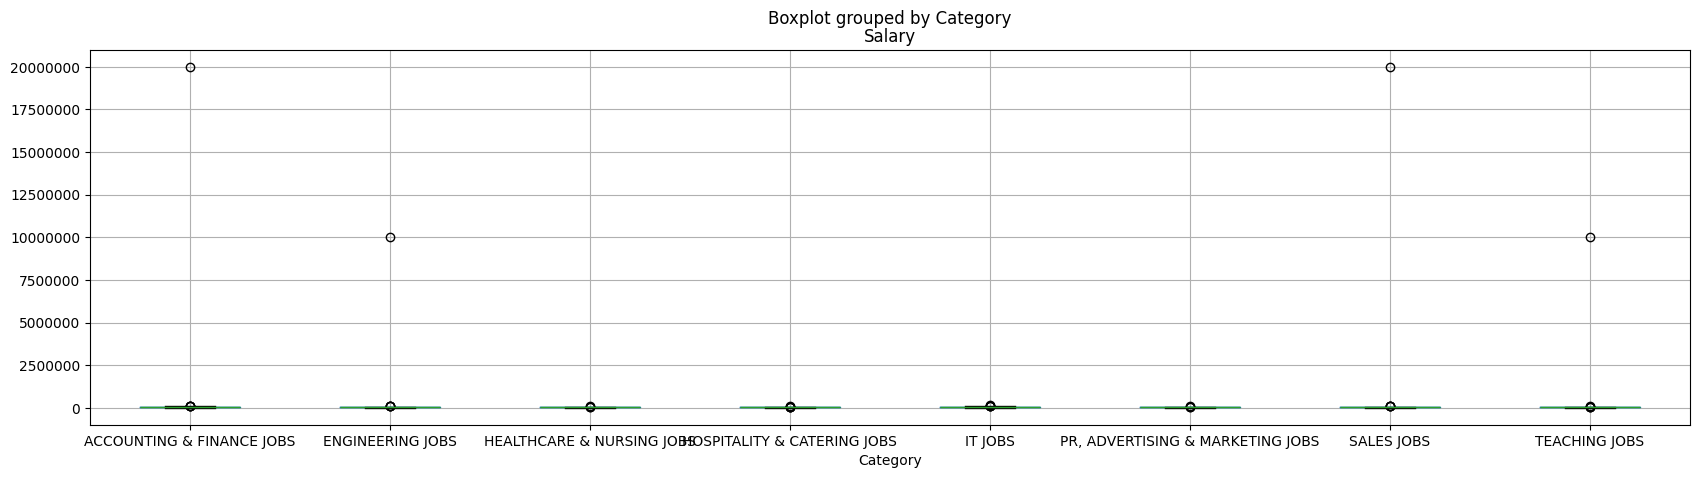

In [48]:
dataset.dropna(subset= ['Salary']).boxplot('Salary', by = 'Category', figsize=(20, 5))
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

From the boxpot we can see that there are extreme outliers on some of the columns. With the formula that was mentioned before. Each column outliers will be dealt with.

Outliers are dealt by columns respectively. This is done so that we can detect outliers correctly. If we done it for all column at the same time then the lower outliers like in the IT jobs won't be detected because the upper fence will be skewed because of the extreme outlier from accounting and finance job. Then the outliers are converted into NaN values.

In [49]:
#Making a list of all the category values
cat_list = dataset.Category.unique().tolist()

#Making a for loop to detect outliers in each column
for x in cat_list:
    #Entering the values of each column into variable
    salary = dataset.loc[(dataset['Category'] == x), 'Salary'].dropna()

    #Formula to count the q3,q1 and iqr
    q3, q1 = np.percentile(salary, [75, 25])
    iqr = q3 - q1

    #Counting the Upper and Lower fence
    out_q1 = q1 - iqr*1.5
    out_q3 = q3 + iqr*1.5

    #Showing upper outlier for each column
    print('Upper Outlier for category', x)
    print(dataset.loc[(dataset['Category'] == x) & (dataset['Salary'] > (out_q3)), 'Salary'])

    #Converting the outliers into NaN values and applying it to the column
    dataset.loc[(dataset['Category'] == x) & (dataset['Salary'] > (out_q3)), 'Salary'] = np.nan

    #Showing the lower outlier for each column
    print('Lower Outlier for category', x)
    print(dataset.loc[(dataset['Category'] == x) & (dataset['Salary'] < (out_q1)), 'Salary'])
    
    #Converting the outliers into NaN values and applying it to the column
    dataset.loc[(dataset['Category'] == x) & (dataset['Salary'] < (out_q1)), 'Salary'] = np.nan

Upper Outlier for category ENGINEERING JOBS
16538       78221.0
25667       79033.0
25912       79495.0
26972    10000000.0
48362       80000.0
Name: Salary, dtype: float64
Lower Outlier for category ENGINEERING JOBS
Series([], Name: Salary, dtype: float64)
Upper Outlier for category ACCOUNTING & FINANCE JOBS
11262      123820.0
30087      113423.0
42826    20000000.0
50587      100000.0
54476      119549.0
Name: Salary, dtype: float64
Lower Outlier for category ACCOUNTING & FINANCE JOBS
Series([], Name: Salary, dtype: float64)
Upper Outlier for category HEALTHCARE & NURSING JOBS
135      71748.0
35250    72625.0
54149    75604.0
Name: Salary, dtype: float64
Lower Outlier for category HEALTHCARE & NURSING JOBS
Series([], Name: Salary, dtype: float64)
Upper Outlier for category HOSPITALITY & CATERING JOBS
9595     80000.0
36235    53705.0
36509    50909.0
41473    46963.0
47816    60000.0
Name: Salary, dtype: float64
Lower Outlier for category HOSPITALITY & CATERING JOBS
Series([], Name

Next is NumberOfViews column

# NumberOfViews

First value counts and for loop is used to skim the problem with the NumbeOfViews column

In [50]:
#Code to skim the problem with Salary Column
for x,y in dataset.NumberOfViews.value_counts().to_dict().items():
    print(x,y)

- 847
XX 842
0 806
28020 31
23988 30
28017 28
27980 28
26048 28
24035 28
31967 28
28022 27
27983 27
23954 27
23998 27
31971 27
35966 26
23952 26
27962 26
28036 25
29981 25
23979 25
31980 25
27979 25
26023 25
23976 24
27991 24
28009 24
27976 24
23950 24
31981 24
23987 24
36016 24
24034 24
28041 24
27981 23
28007 23
32001 23
27999 23
31962 23
27953 23
24027 23
28014 23
32006 23
23970 23
23983 23
31966 23
24006 23
28049 23
32018 23
23956 23
28039 23
36040 23
25985 23
28025 23
28035 23
28032 23
23996 22
36020 22
24048 22
27963 22
19975 22
27951 22
24005 22
30039 22
23962 22
32025 22
32019 22
28010 22
27964 22
30034 22
32034 21
26008 21
26044 21
23965 21
23991 21
27966 21
24022 21
24012 21
31963 21
24031 21
24037 21
23989 21
32026 21
24030 21
24018 21
28018 21
20012 21
32039 21
24014 21
35983 21
36042 21
27987 21
23980 20
19971 20
25991 20
29994 20
27954 20
40042 20
32022 20
36039 20
24036 20
24016 20
19960 20
27952 20
32030 20
28042 20
24017 20
32029 20
23982 20
27967 20
36006 20
27985 20


Looks like there are still 0, XX, and - values. They are not valid values because it should be in integer values so all of them are converted into NaN values

In [51]:
#Converting the 0, XX, and - into NaN
dataset.NumberOfViews.replace('XX', np.nan, inplace=True)
dataset.NumberOfViews.replace('0', np.nan, inplace=True)
dataset.NumberOfViews.replace('-', np.nan, inplace=True)

The global schema asked the NumberOfViews column to be integer therefore it is converted into integer

In [52]:
#Converting the NumberOfViews column into integer
dataset['NumberOfViews'] = pd.to_numeric(dataset.NumberOfViews, downcast='integer', errors='coerce')

Then we check if it's already converted into integer

In [53]:
#Checking if the column already converted into integer
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55171 entries, 0 to 55170
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             55171 non-null  int64  
 1   Title          55171 non-null  object 
 2   Location       55171 non-null  object 
 3   Company        49782 non-null  object 
 4   ContractType   33494 non-null  object 
 5   ContractTime   47049 non-null  object 
 6   Category       55171 non-null  object 
 7   Salary         52404 non-null  float64
 8   OpenDate       55171 non-null  object 
 9   CloseDate      55171 non-null  object 
 10  SourceName     55171 non-null  object 
 11  NumberOfViews  50150 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 5.1+ MB


Looks like the values is still in float. This happened because there are still missing values in the column. So after we dealt with the missing values we'll convert the column again into integer. Next we'll check for the outliers again with boxplot first

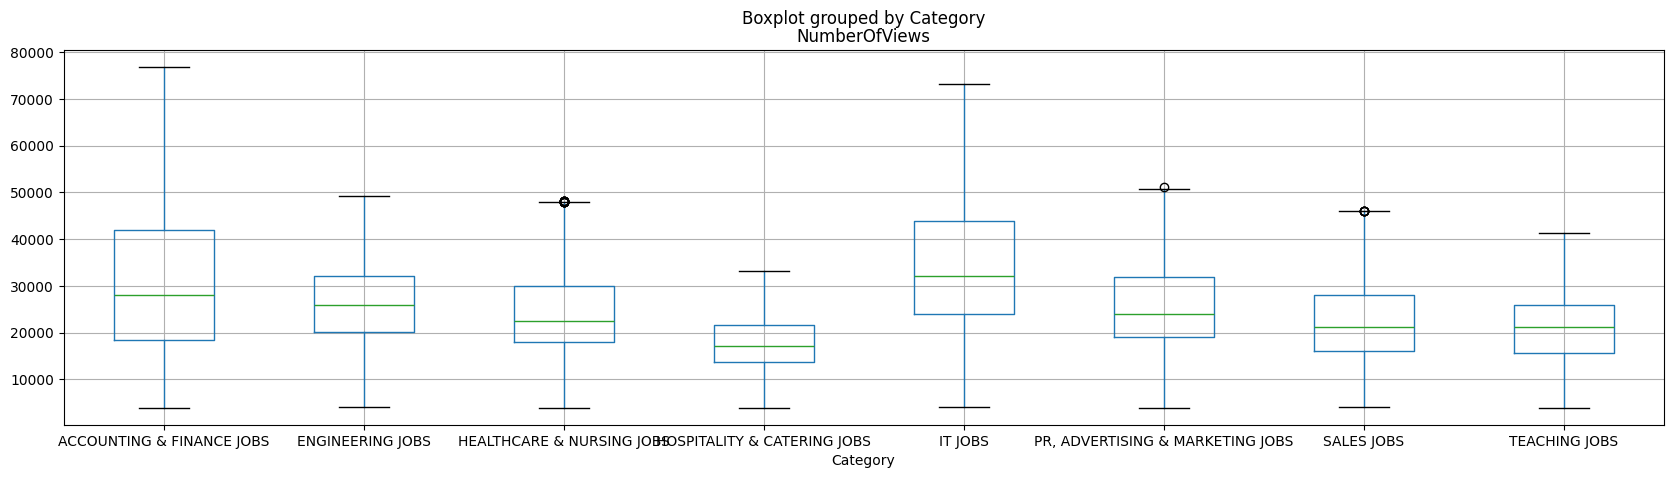

In [54]:
#Checking outliers for NumberOfViews column with boxplot
dataset.dropna(subset= ['NumberOfViews']).boxplot('NumberOfViews', by = 'Category', figsize=(20, 5))
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

Looks like there are outliers in some of the column. Like in the Salary column, it's better to deal with the outliers with the upper and lower fence formula therefore the method we did in Salary column is implemented again here

In [55]:
#Dealing with outliers using the formula like in the Salary column

#Making a for loop to detect outliers in each column
for x in cat_list:
    #Entering the values of each column into variable
    noview = dataset.loc[(dataset['Category'] == x), 'NumberOfViews'].dropna()

    #Formula to count the q3,q1 and iqr
    q3, q1 = np.percentile(noview, [75, 25])
    iqr = q3 - q1

    #Counting the Upper and Lower fence
    out_q1 = q1 - iqr*1.5
    out_q3 = q3 + iqr*1.5

    #Showing upper outlier for each column
    print('Upper Outlier for category', x)
    print(dataset.loc[(dataset['Category'] == x) & (dataset['NumberOfViews'] > (out_q3)), 'NumberOfViews'])

    #Converting the outliers into NaN values and applying it to the column
    dataset.loc[(dataset['Category'] == x) & (dataset['NumberOfViews'] > (out_q3)), 'NumberOfViews'] = np.nan

    #Showing the lower outlier for each column
    print('Lower Outlier for category', x)
    print(dataset.loc[(dataset['Category'] == x) & (dataset['NumberOfViews'] < (out_q1)), 'NumberOfViews'])

    #Converting the outliers into NaN values and applying it to the column
    dataset.loc[(dataset['Category'] == x) & (dataset['NumberOfViews'] < (out_q1)), 'NumberOfViews'] = np.nan


Upper Outlier for category ENGINEERING JOBS
Series([], Name: NumberOfViews, dtype: float64)
Lower Outlier for category ENGINEERING JOBS
Series([], Name: NumberOfViews, dtype: float64)
Upper Outlier for category ACCOUNTING & FINANCE JOBS
Series([], Name: NumberOfViews, dtype: float64)
Lower Outlier for category ACCOUNTING & FINANCE JOBS
Series([], Name: NumberOfViews, dtype: float64)
Upper Outlier for category HEALTHCARE & NURSING JOBS
280      48047.0
754      48041.0
6431     48039.0
22672    48047.0
30572    48030.0
30586    48034.0
33833    48035.0
36412    48048.0
39929    48026.0
41251    48026.0
44876    48040.0
52323    48033.0
53620    48028.0
Name: NumberOfViews, dtype: float64
Lower Outlier for category HEALTHCARE & NURSING JOBS
Series([], Name: NumberOfViews, dtype: float64)
Upper Outlier for category HOSPITALITY & CATERING JOBS
Series([], Name: NumberOfViews, dtype: float64)
Lower Outlier for category HOSPITALITY & CATERING JOBS
Series([], Name: NumberOfViews, dtype: float6

Next we deal with duplicates

# DUPLICATES

To search for duplicates, duplicated function is used. The condition is with Title, Location, and Category.

- Title is choosen because it's more likely that the name could be the same
- OpenDate and CloseDate is choosen because if the duplicated rows has the same name and has the same OpenDate and CloseDate with each other,
it's more likely that it's a duplication

In [56]:
#Function to show duplicates based from Title,OpenDate, and CloseDate column
dataset[dataset.duplicated(['Title', 'OpenDate', 'CloseDate'], keep=False)].sort_values(['Title'])

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName,NumberOfViews
54484,72653751,BARCLAYS FUTURE LEADERS DEVELOPMENT PROGRAMMES,HACKNEY,BARCLAYS,non_specified,non_specified,IT JOBS,36000.0,20121223T150000,20130221T150000,grb.uk.com,28847.0
55169,72705240,BARCLAYS FUTURE LEADERS DEVELOPMENT PROGRAMMES,HACKNEY,BARCLAYS,non_specified,non_specified,IT JOBS,36000.0,20121223T150000,20130221T150000,grb.uk.com,NaN
5869,72705504,MOBILE SERVICE ENGINEER/FITTER,SOUTH EAST LONDON,360 RECRUITMENT LTD,non_specified,permanent,ENGINEERING JOBS,24959.0,20120403T120000,20120503T120000,totaljobs.com,19981.0
50751,72239662,MOBILE SERVICE ENGINEER/FITTER,SOUTH EAST LONDON,360 RECRUITMENT LTD,non_specified,permanent,ENGINEERING JOBS,24960.0,20120403T120000,20120503T120000,totaljobs.com,19982.0
47472,71808610,PENSIONS ADMINISTRATORS (TEMPORARY/CONTRACT),UK,ABENEFIT2U,non_specified,contract,ACCOUNTING & FINANCE JOBS,24000.0,20130801T150000,20130831T150000,professionalpensionsjobs.com,19240.0
55167,72705205,PENSIONS ADMINISTRATORS (TEMPORARY/CONTRACT),UK,ABENEFIT2U,NaN,contract,ACCOUNTING & FINANCE JOBS,24000.0,20130801T150000,20130831T150000,cv-library.co.uk,NaN
8024,67290277,QUALITY ASSURANCE ENVIRONMENTAL MANAGER NOTTIN...,NOTTINGHAM,STEPHEN JAMES CONSULTING,NaN,permanent,HEALTHCARE & NURSING JOBS,35000.0,20120110T150000,20120409T150000,tntjobs.co.uk,27953.0
55170,72705244,QUALITY ASSURANCE ENVIRONMENTAL MANAGER NOTTIN...,NOTTINGHAM,STEPHEN JAMES CONSULTING,NaN,permanent,HEALTHCARE & NURSING JOBS,35000.0,20120110T150000,20120409T150000,tntjobs.co.uk,NaN
34676,70086310,SENIOR FINANCIAL ADVISOR,LONDON,FRAM EXECUTIVE SEARCH,non_specified,permanent,ACCOUNTING & FINANCE JOBS,40000.0,20130126T000000,20130225T000000,ifaonlinejobs.co.uk,31999.0
55168,72705221,SENIOR FINANCIAL ADVISOR,LONDON,FRAM EXECUTIVE SEARCH,non_specified,permanent,ACCOUNTING & FINANCE JOBS,40000.0,20130126T000000,20130225T000000,ifaonlinejobs.co.uk,NaN


We can see that there are some rows that looks like it's duplicated. All of the rows looks the same as the one above. 

The one exception is the Waitress in VIP Restaurant Bar which company have LTD in the 2nd row. But this could be explained that they are actually the same company since the name is the same minus the LTD. The other rows except the Id are also the same. (Salary has additional 1 but it's almost the same so this looks like a duplication)

We assume that the duplicated columns are the second one because according to the index, the columns are inserted sequentially so the second value is the duplicated one maybe because it was inserted again by mistake.

In [57]:
#Dropping the duplicated rows and keeping the first one.
dataset = dataset.drop_duplicates(subset=['Title', 'OpenDate', 'CloseDate'], keep='first')

With this the duplicated rows are already dealt with. Next is the missing values

# MISSING VALUES

Now we will deal with missing values, it's separated for the Non Numerical Column and Numerical Column

# Non Numerical Column

Inserting Missing Values for non numeric column = Company, ContractType, ContractTime

- For Company, mode() is used to fill it with the most frequent row grouped by category
- For ContractTime and ContractType, it's filled with non-specified and non_specified respectively according to the global schema

In [58]:
#Function to use mode() to fill out Na in contract type grouping by category column
f_ctype = lambda x:x.mode().iloc[0]
dataset.Company = dataset.Company.fillna(dataset.groupby('Category').Company.transform(f_ctype))

#Fill ContractTime with non-specified
dataset.ContractTime.fillna('non-specified', inplace=True)

#Fill ContractType with non_specified
dataset.ContractType.fillna('non_specified', inplace=True)

Then we check the global dataset if the NaN values are already inputted

In [59]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55165 entries, 0 to 55166
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             55165 non-null  int64  
 1   Title          55165 non-null  object 
 2   Location       55165 non-null  object 
 3   Company        55165 non-null  object 
 4   ContractType   55165 non-null  object 
 5   ContractTime   55165 non-null  object 
 6   Category       55165 non-null  object 
 7   Salary         52398 non-null  float64
 8   OpenDate       55165 non-null  object 
 9   CloseDate      55165 non-null  object 
 10  SourceName     55165 non-null  object 
 11  NumberOfViews  50129 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 5.5+ MB


Looks like Company, ContractType, and ContractTime NaN values are all already inputted. Next for the numerical values

# Numerical Values

For the numerical values, there are two ways to do it which is inputting by Statistical means (mean, median) or by machine learning method (linear regression). Before applying in on the task ipnyb, the machine learning method is already tested and the RMSE value was in ten thousands with R^2 value in the 0.25 range. Looking at the bad value of the predictions, there's not much value in using machine learning method with inputting the means being the faster way so input mean value is used for both column. The mean is grouped by Category column for both Salary and Number of Views

In [60]:
#Function to fill Salary NaN values column with mean grouped by Category column
dataset["Salary"].fillna(dataset.groupby("Category")["Salary"].transform("mean"), inplace=True)
dataset.Salary.describe()

count    55165.000000
mean     34402.280739
std      15522.838666
min       5000.000000
25%      23300.000000
50%      31500.000000
75%      42500.000000
max      96000.000000
Name: Salary, dtype: float64

In [61]:
#Function to fill NumberOfViews NaN values column with mean grouped by Category column
dataset["NumberOfViews"].fillna(dataset.groupby("Category")["NumberOfViews"].transform("mean"), inplace=True)
dataset.NumberOfViews.describe()

count    55165.000000
mean     27455.496535
std      12155.454805
min       3957.000000
25%      18818.000000
50%      25200.000000
75%      33976.000000
max      76841.000000
Name: NumberOfViews, dtype: float64

Then we look at the global dataset again to see if the NaN values are already inputted for both Salary and NumberOfViews column

In [62]:
#Looking if Salary and NumberOfViews column are updated
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55165 entries, 0 to 55166
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             55165 non-null  int64  
 1   Title          55165 non-null  object 
 2   Location       55165 non-null  object 
 3   Company        55165 non-null  object 
 4   ContractType   55165 non-null  object 
 5   ContractTime   55165 non-null  object 
 6   Category       55165 non-null  object 
 7   Salary         55165 non-null  float64
 8   OpenDate       55165 non-null  object 
 9   CloseDate      55165 non-null  object 
 10  SourceName     55165 non-null  object 
 11  NumberOfViews  55165 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 5.5+ MB


Looking at the output, looks like NumberOfViews column is still in float format. The global schema requested it to be Integer therefore it's changed

In [63]:
#Function to convert NumberOfViews column from float to integer values
dataset['NumberOfViews'] = np.floor(pd.to_numeric(dataset['NumberOfViews'], errors='coerce')).astype('Int64')

Checking again if it's already converted

In [64]:
#Checking if NumberOfViews are already in integer
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55165 entries, 0 to 55166
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             55165 non-null  int64  
 1   Title          55165 non-null  object 
 2   Location       55165 non-null  object 
 3   Company        55165 non-null  object 
 4   ContractType   55165 non-null  object 
 5   ContractTime   55165 non-null  object 
 6   Category       55165 non-null  object 
 7   Salary         55165 non-null  float64
 8   OpenDate       55165 non-null  object 
 9   CloseDate      55165 non-null  object 
 10  SourceName     55165 non-null  object 
 11  NumberOfViews  55165 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(9)
memory usage: 5.5+ MB


Looks like it's already updated. One thing we should check after inputting the NaN values is the outlier for both column. Therefore both column are checked again for outlier.

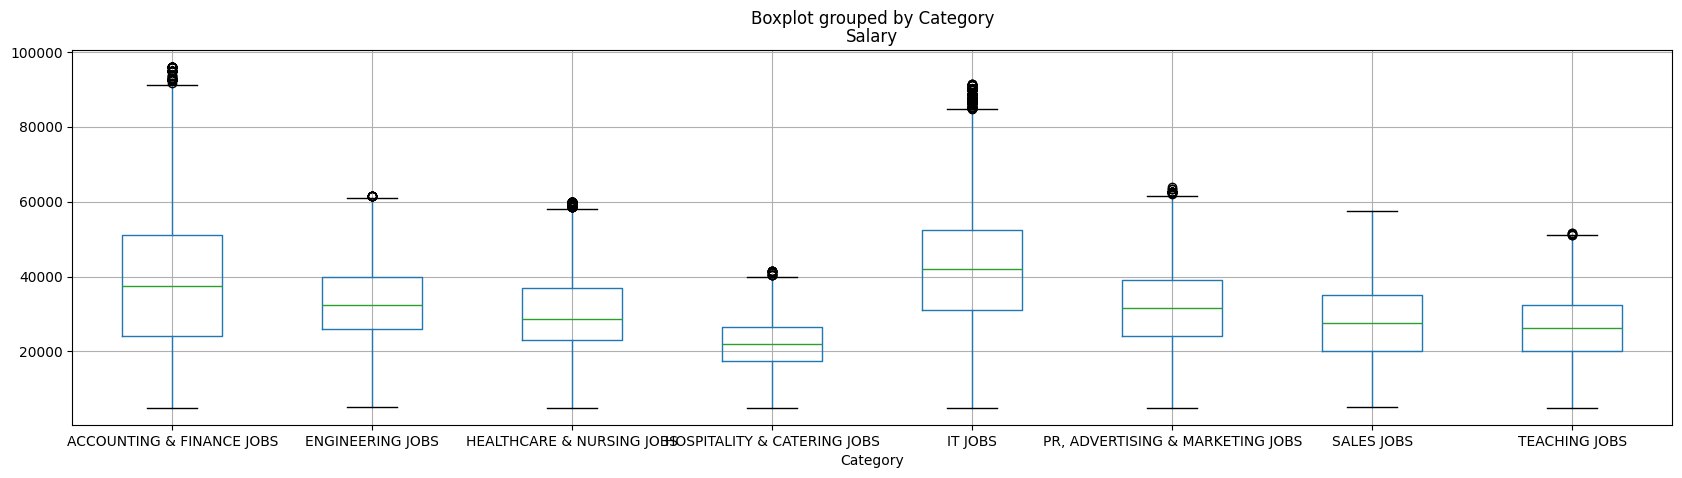

In [65]:
#Code to show boxplot again for Salary to check for outliers grouped by Category column
dataset.boxplot('Salary', by = 'Category', figsize=(20, 5))
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

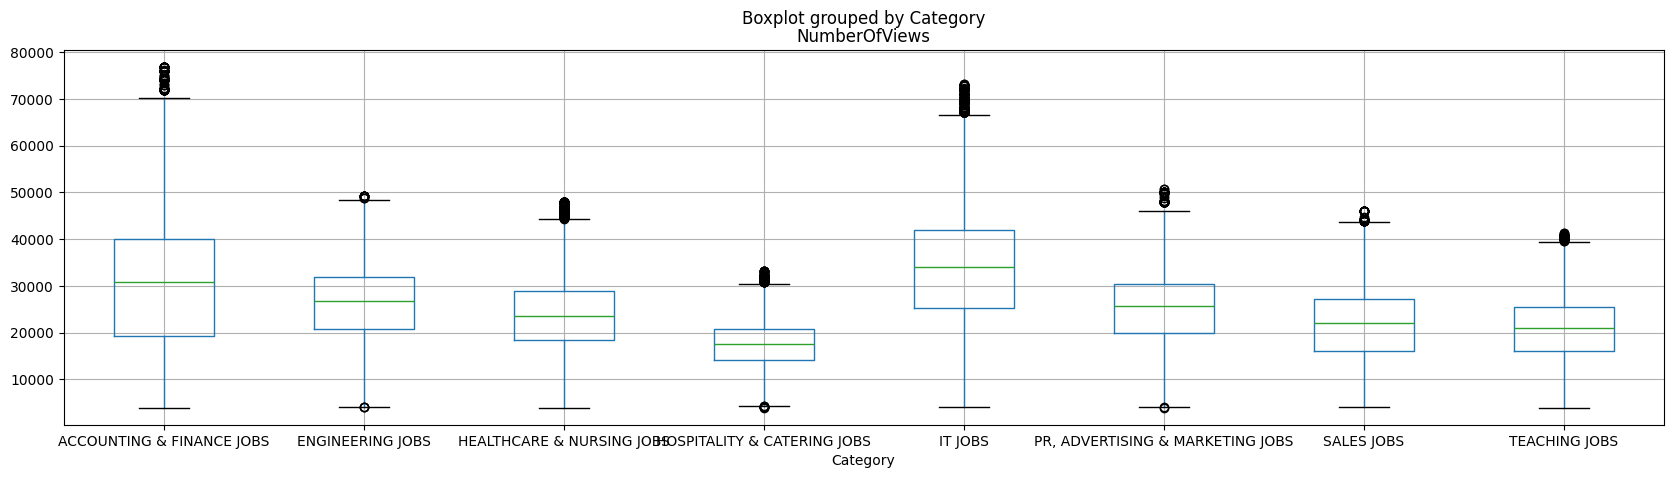

In [66]:
#Code to show boxplot again for NumberOfViews to check for outliers grouped by Category column
dataset.boxplot('NumberOfViews', by = 'Category', figsize=(20, 5))
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

As we can see, both column still has outliers and one might think we should correct this again. But the problem is, the outlier appeared because we entered the missing values by inputting the mean values based on it's category. 

If we delete the outlier again and reinput the outliers, we would actually be deleting the correct values that were actually weren't outliers from the boxplot  and function we made before. This happened because by inputting the missing values based on it's mean, the spread of the data is pulled to the means, therefore the values at the upper and lower fence will become the new outlier. Because of this, the new outliers weren't dealt with. 

So finally the work for task 1 is finished. The dataframe is saved into csv file with the correct name.

# Save data

Finally the dataset is saved into csv with the correct name

In [67]:
# code to save output data
dataset.to_csv("dataset1_solution.csv",index = False)

## Summary
Give a short summary and anything you would like to talk about assessment 2 part 1 here.

In the first task I did the data wrangling for dataset 1 with mistakes. First I EDA the dataset then from there I check every column and wrangled them as needed. The missing values is discussed after checking every column is discussed (Column with missing values are Company, Salary, ContractType, ContractTime, NumberOfViews)

# Id

For the Id column, I checked it's integrity, if it's match what was asked from the global schema. I didn't found any mistakes then I moved on

# Title

For the title column, I found that there are upper case and lower case, and with & symbol inconsistency, and trailing spaces. So I normalized the column so that the column is normalized

# Location

For the location column, I found that there are upper case and lower case, and with & symbol inconsistency. There's also typos so the column is normalized then the typos are corrected

# Company

For the company column, I found that there are upper case and lower case, and with & symbol inconsistency, also spaces and typos problem. For the first three problems, it was resolved by normalizing the column. For the typos, it's not possible to know the correct names therefore the low count names are string matched with high count names. Spaces, ., and - is converted to missing values

# ContractType

For the ContractType column, I found that there are incorrect symbols, therefore those are changed to non-specified according to the global schema

# ContractTime

For the ContractTime column, I found that there are incorrect symbols, therefore those are changed to non-specified according to the global schema

# Category

For the CategoryTime column, I found that there are typos, and vs & symbol, and incorrect names. First the column are normalized to upper case then the and is converted to &. Then the wrong names are corrected.

# OpenDate and CloseDate

Both columns are checked if there's any data that violates the global schema. Then it's checked if there's any invalid dates in any of the column (month bigger than 12 for example). Finally both column are compared for integrity if there's any opendate that's later than the closedate or vice versa then it's corrected

# Salary

For the Salary column, I found that there are inconsistency with the salary itself (number ending with K, range of numbers, salary per hour or year). All of them are dealt with appropriately. There are also incorrect values like - or 0. Those are converted to null values and will be dealt later. Then the column is checked for outliers, all found outliers are converted to nan values.

# SourceName

For the SourceName clear mistakes is the column name actually doesn't match the global schema therefore it is corrected. Next some of the values are actually not correct website so they are searched on the internet and corrected

# NumberOfViews

For the NumberOfViews column, I found that there are invalid columns (XX, 0, -). Those are converted to missing values.

# Duplicates

After the data is wrangled, duplicates of the data is checked by Title, OpenDate, and CloseDate column then the found duplicates are deleted

# Missing Values

## Non Numeric

For the non numeric missing values (Company, ContractType, ContractTime), for company it's is inserted by the most frequent values grouped by category. Meanwhile for both contracts column, they are replaced by non_specified

## Numeric

Both Salary and NumberOfViews missing values are inserted by mean grouped by category. After this process, outliers will emerge again but it's left as it is because the current outlier is actually the upper and lower fence from before


# SavetoCsv

Finally the data is saved to dataset1_solution as requested in the pdf